LSI ND mra and natural domain layer (1D, 2D, 3D)

---

Kishore Kumar Tarafdar, 04Jul2025

        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-04 02:04:39.771421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751574879.791891 1464527 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751574879.798211 1464527 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-04 02:04:39.820216: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D


2025-07-03 00:36:15.856100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751483175.876905  262888 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751483175.883276  262888 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 00:36:15.905080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751483177.993279  262888 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [155]:
# mylibpath = [
#     '/data1/kishoretarafdar/src.port/VolterraMRAsystems.v0/linear.Volterra.mra.live/mra'
#     ]
# import sys
# [sys.path.insert(1,_) for _ in mylibpath]
# del mylibpath
# from DWT1DFB import DWT1D, IDWT1D

In [2]:
import matplotlib.pyplot as plt

#  MIMO batch
        
        export to py file

In [ ]:

#%% Shift invariant Linear (m=1) Multiresolution Volterra Kernel
import tensorflow as tf
import keras
from TFDWT.DWT1DFB import DWT1D, IDWT1D

@tf.keras.utils.register_keras_serializable()
class LSIVolterraNDlayout(tf.keras.layers.Layer):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
        Input: sequence x[n]
        Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@04Jul2025"""
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
        self.wave = wave
        if self.wave is None: self.mra = False
        else: self.mra = True

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.axes = list(range(1, len(input_shape) - 1))
        self.dim = self.axes[-1]
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        # kernel_shape = (self.L, self.channels, self.filters)
        kernel_shape = [self.L] * self.dim + [self.channels, self.filters]
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel')
        super().build(input_shape)
    
    def call(self, x):
        pass
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
            'mra': self.mra
        })
        return config

# LSI 1D mra and natural kernel

In [58]:

#%% Shift invariant Linear (m=1) Multiresolution Volterra Kernel
import tensorflow as tf
import keras
from TFDWT.DWT1DFB import DWT1D, IDWT1D

@tf.keras.utils.register_keras_serializable()
class LSIVolterra1D(LSIVolterraNDlayout):
    """ LSI 1D mra and natural kernel
    
        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
        Input: sequence x[n]
        Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@04Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(filters=filters, kernel_size=kernel_size, wave=wave, **kwargs)

    def __makeH(self):
        paddings = [
        [0, self.N - self.L],  # Depth dimension
        [0,0],
        [0,0]
        ]
        h_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)
        # print(h_padded.shape,'>')

        ## Creating x[n-k] for all n
        n = tf.range(self.N)
        self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)

        h1_shifted = tf.gather(h_padded, self.row_indices, axis=0)
        self.h1_shifted = h1_shifted
        # print(hshifted.shape,'>')
        # print(tf.concat([tf.transpose(DWT1D(self.wave)(tf.transpose(DWT1D(self.wave)(hshifted[...,i:i+1]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)], axis=-1))

        if self.mra==False: return h1_shifted ## natural shifted kernel
        else: ## shifted MRA kernel

            # ### PERFECT but slow
            # HT = tf.stack([
            #         tf.concat([
            #             tf.transpose(DWT1D(self.wave, clean=False)(tf.transpose(DWT1D(self.wave, clean=False)(hshifted[...,i:i+1,j]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)
            #             ], axis=-1) for j in range(self.filters)], axis=-1)
            # # print(HT.shape)
            # return HT
        
            ## UPDATED
            # Vectorized: flatten last two axes for DWT
            dwt1 = DWT1D(self.wave, clean=False)
            tmp_h_for_dwt = tf.reshape(h1_shifted, (self.N, self.N, self.channels * self.filters))
            ## x is dummy here
            x = dwt1(tmp_h_for_dwt)           # (N, dwt_len, in_channels*out_channels)
            # 3. Transpose to swap axes 0 and 1 ("rows" and "columns")
            xT = tf.transpose(x, perm=[1, 0, 2])  # (N', N, in_channels * out_channels)

            # 4. DWT1D along the original rows (now axis=1)
            x2 = dwt1(xT)  # (N', N'', in_channels * out_channels)

            # 5. Transpose back to original orientation
            x2T = tf.transpose(x2, perm=[1, 0, 2])  # (N'', N', in_channels * out_channels)

            # 6. Reshape back to (N'', N', in_channels, out_channels)
            HT = tf.reshape(x2T, (self.N, self.N, self.channels, self.channels))
            return HT

    def call(self, x):
        self.x = x
        if self.mra==True: return self._call_with_mra_kernel(x)   
        else: return self._call_in_natural_domain(x)
    
    def _call_with_mra_kernel(self, x):  
        ## H[v,l] 
        α = DWT1D(self.wave, clean=False)(x) 
        # print('α = ', α.shape)
        HT = self.__makeH()
        print('HT and α', HT.shape, α.shape)
        β = tf.einsum('bic,uico->buo', α, HT)
        # β = tf.einsum('buco->buo',β)
        print('β', β.shape)
        y = IDWT1D(self.wave, clean=False)(β)#
        # print('y',tf.squeeze(y).numpy())
        return y#, ynatural

    def _call_in_natural_domain(self, x):
        h1_shifted = self.__makeH() ##dummy!!
        return tf.einsum('bic,rico->bro', x, self.h1_shifted)

    def sanity_check(self):
        return self._call_with_mra_kernel(self.x), self._call_in_natural_domain(self.x)  



if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"  
    ## Example 2
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    inputs = tf.keras.Input(shape=input_shape)
    H = LSIVolterra1D(filters=1, wave='haar')
    H = LSIVolterra1D(filters=1, wave=None)

    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    # Random data
    ## 1D
    x = tf.random.normal((1, N, 1))
    y = tf.random.normal((1, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(x, y, epochs=5, verbose=1)
    del x, y, inputs, outputs

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra1d_21               │ (None, 4, 1)           │             4 │
│ (LSIVolterra1D)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 1.5656
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.5604
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.5552
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5501
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5450


In [59]:
## Example 1    
lay = LSIVolterra1D(filters=1, wave='haar')
## sample batch input
# x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# _ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
x = tf.random.normal((1, 128, 1))
x.shape
y = lay(x)
y.shape

HT and α (128, 128, 1, 1) (1, 128, 1)
β (1, 128, 1)


TensorShape([1, 128, 1])

HT and α (128, 128, 1, 1) (1, 128, 1)
β (1, 128, 1)


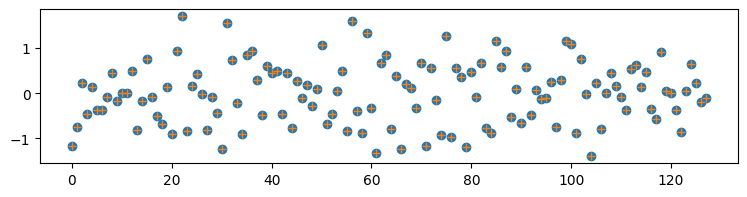

In [60]:
y, ynat = lay.sanity_check()
plt.figure(figsize=(9,2))
plt.plot(tf.squeeze(y).numpy(), 'o')
plt.plot(tf.squeeze(ynat).numpy(), '+')

In [ ]:
# x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
# x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
x.shape

TensorShape([16])

# LSI 2D mra and natural domain kernel

In [62]:
import tensorflow as tf
import keras
from TFDWT.DWT2DFB import DWT2D, IDWT2D

@tf.keras.utils.register_keras_serializable()
class LSIVolterra2D(LSIVolterraNDlayout):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>. 
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
       Input: image x[n1,n2]
       Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@04Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(filters=filters, kernel_size=kernel_size, wave=wave, **kwargs)

    def __makeH(self):
        # Npoint = self.N
        paddings = [
        [0, self.N - self.L],  # height dimension
        [0, self.N - self.L],  # width dimension
        [0,0],
        [0,0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, k1, k2
        n1 = tf.range(self.N)  # [0, 1, ..., N-1]
        n2 = tf.range(self.N)  # [0, 1, ..., N-1]
        k1 = tf.range(self.N)  # [0, 1, ..., N-1]
        k2 = tf.range(self.N)  # [0, 1, ..., N-1]

        # Create a grid of indices for n1, n2, k1, k2
        n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Circular shift for n1
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Circular shift for n2

        # Gather the values from h using the shifted indices
        h1_shifted = tf.gather_nd(h1, tf.stack([shifted_n1, shifted_n2], axis=-1))
        # h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4,5])  # n1,:,:,n2 01234 ## very important line!!
        # print('++', h1_shifted.shape)
        self.h1_shifted = h1_shifted
        if self.mra == False: return self.h1_shifted
        else:               
            # ### second vectorized upgrade
            def dwtmra(h1_shifted):
                # # h1_shifted: (N, N, N, N, in_channels, out_channels)
                N, in_channels, out_channels = self.N, self.channels, self.filters
                num_io = in_channels * out_channels

                # Flatten (in, out) for DWT2D
                hflat = tf.reshape(h1_shifted, (N, N, N, N, num_io))
                hflat_reshape = tf.reshape(hflat, (N*N, N, N, num_io))

                dwt2d = DWT2D(self.wave, clean=False)
                x1 = dwt2d(tf.cast(hflat_reshape, tf.float32))
                x1r = tf.reshape(x1, (N, N, N, N, num_io))

                # Transpose for columnplanewise DWT2D
                x1T = tf.transpose(x1r, [2, 3, 0, 1, 4])
                x1T_reshape = tf.reshape(x1T, (N*N, N, N, num_io))
                x2 = dwt2d(x1T_reshape)
                x2r = tf.reshape(x2, (N, N, N, N, num_io))

                # Transpose back
                HT = tf.transpose(x2r, [2, 3, 0, 1, 4])
                HT = tf.reshape(HT, (N, N, N, N, in_channels, out_channels))
                # print('++', HT.shape)
                return HT
            return dwtmra(h1_shifted)   

    def call(self, x):
        self.x = x
        if self.mra==True: return self._call_with_mra_kernel(x)   
        else: return self._call_in_natural_domain(x)  

    def _call_with_mra_kernel(self, x):
        # HT = self.__getH()
        α = DWT2D(self.wave, clean=False)(tf.cast(x, dtype=tf.float32))
        # α.shape
        HT = self.__makeH()
        ## convolution like in wavelet domain
        # β = tf.einsum('bijc,uijvco->buvco', α, self.HT) #ok
        β = tf.einsum('bijc,uvijco->buvo', α, HT)
        # β = tf.einsum('buvco->buvo',β)
        # β
        y = IDWT2D(self.wave, clean=False)(β)
        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        return y#, ynatural

    def _call_in_natural_domain(self, x):
        h1_shifted = self.__makeH() ##dummy!!
        return tf.einsum('bijc,uvijco->buvo', x, self.h1_shifted)

    def sanity_check(self):
        return self._call_with_mra_kernel(self.x), self._call_in_natural_domain(self.x)  


if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"   
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, N, channels) 
    inputs = tf.keras.Input(shape=input_shape)
    H = LSIVolterra2D(filters=1)
    H = LSIVolterra2D(filters=1, wave=None)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 2D
    inputs_data = tf.random.normal((1, N, N, 1))
    targets = tf.random.normal((1, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 4, 4, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra2d_10               │ (None, 4, 4, 1)        │            16 │
│ (LSIVolterra2D)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 3.0231
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.0044
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.9858
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.9673
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.9489


In [65]:
## Example 1    
lay = LSIVolterra2D(filters=1, wave='haar')
## sample batch input
# x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# _ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
x = tf.random.normal((1, 8, 8, 1))
x.shape
y = lay(x)
y.shape

(4, 8) (4, 8) H0, H1
(8, 8) (1, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(1, 8, 8, 1) +
(4, 8) (4, 8) H0, H1
(8, 8) (64, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(64, 8, 8, 1) +
(8, 8) (64, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(64, 8, 8, 1) +


TensorShape([1, 8, 8, 1])

(4, 8) (4, 8) H0, H1
(8, 8) (1, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(1, 8, 8, 1) +
(4, 8) (4, 8) H0, H1
(8, 8) (64, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(64, 8, 8, 1) +
(8, 8) (64, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(64, 8, 8, 1) +
(4, 8) (4, 8) H0, H1
(8, 8) (64, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(64, 8, 8, 1) +
(8, 8) (64, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(64, 8, 8, 1) +


(<Axes: >, <matplotlib.image.AxesImage at 0x7f9a807afa70>)

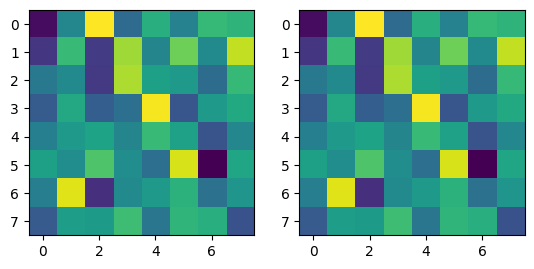

In [66]:
y, ynat = lay.sanity_check()
# plt.figure(figsize=(9,))
plt.subplot(121), plt.imshow(tf.squeeze(y).numpy())
plt.subplot(122), plt.imshow(tf.squeeze(ynat).numpy())

# LSI 3D mra and natural domain kernel

In [72]:
import tensorflow as tf
import keras
from TFDWT.DWT3DFB import DWT3D, IDWT3D

@tf.keras.utils.register_keras_serializable()
class LSIVolterra3D(LSIVolterraNDlayout):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>. 
        
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
       Input: volumetric image x[n1,n2,n3]
       Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@03Jul2025"""
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(filters=filters, kernel_size=kernel_size, wave=wave, **kwargs)

        
    def __makeH(self):
        paddings = [
            [0, self.N - self.L],  # depth dimension
            [0, self.N - self.L],  # height dimension
            [0, self.N - self.L],  # width dimension
            [0, 0],
            [0, 0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, n3, k1, k2, k3
        n1 = tf.range(self.N)  # depth indices
        n2 = tf.range(self.N)  # height indices
        n3 = tf.range(self.N)  # width indices
        k1 = tf.range(self.N)  # depth shift
        k2 = tf.range(self.N)  # height shift
        k3 = tf.range(self.N)  # width shift

        # meshgrid for all dims
        n1, n2, n3, k1, k2, k3 = tf.meshgrid(n1, n2, n3, k1, k2, k3, indexing='ij')  # Shape (N, N, N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Depth shift
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Height shift
        shifted_n3 = tf.math.mod(n3 - k3, self.N)  # Width shift

        # Gather the values from h1 using the shifted indices
        # h1: shape [N, N, N, ...]
        # Need to stack the indices as [shifted_n1, shifted_n2, shifted_n3]
        idx = tf.stack([shifted_n1, shifted_n2, shifted_n3], axis=-1)  # shape (..., 3)
        h1_shifted = tf.gather_nd(h1, idx)  # If h1 has more dimensions, ND gathers all trailing dims

        # h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4,5])  # n1,:,:,n2 01234 ## very important line!!
        # print('++', h1_shifted.shape)
        self.h1_shifted = h1_shifted
        if self.mra == False: return self.h1_shifted
        else:                      
            def dwtmra(h1_shifted):
                # ### second vectorized upgrade!! not matching
                # # h1_shifted: (N, N, N, N, in_channels, out_channels)
                N, in_channels, out_channels = self.N, self.channels, self.filters
                num_io = in_channels * out_channels

                # Flatten (in, out) for DWT2D
                hflat = tf.reshape(h1_shifted, (N, N, N, N, N, N, num_io))
                hflat_reshape = tf.reshape(hflat, (N*N*N, N, N, N, num_io))

                dwt3d = DWT3D(self.wave, clean=False)
                x1 = dwt3d(tf.cast(hflat_reshape, tf.float32))
                x1r = tf.reshape(x1, (N, N, N, N, N, N, num_io))

                # Transpose for columnplanewise DWT2D
                x1T = tf.transpose(x1r, [3, 4, 5, 0, 1, 2, 6])     # <--- This is the key fix
                x1T_reshape = tf.reshape(x1T, (N*N*N, N, N, N, num_io))
                x2 = dwt3d(x1T_reshape)
                x2r = tf.reshape(x2, (N, N, N, N, N, N, num_io))

                # Transpose back
                HT = tf.transpose(x2r, [3, 4, 5, 0, 1, 2, 6])
                HT = tf.reshape(HT, (N, N, N, N, N, N, in_channels, out_channels))
                return HT
            
            return dwtmra(h1_shifted)   

    def call(self, x):
        self.x = x
        if self.mra==True: return self._call_with_mra_kernel(x)   
        else: return self._call_in_natural_domain(x)   

    def _call_with_mra_kernel(self, x):
        α = DWT3D(self.wave, clean=False)(tf.cast(x, dtype=tf.float32))
        # α.shape
        H = self.__makeH()
        ## convolution like in wavelet domain
        β = tf.einsum('bijkc,uvwijkco->buvwo', α, H)
        # β = tf.einsum('buvwco->buvwo',tmpβ)
        # β
        y = IDWT3D(self.wave, clean=False)(β)
        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        return y#, ynatural

    def _call_in_natural_domain(self, x):
        h1_shifted = self.__makeH() ##dummy!!
        return tf.einsum('bijkc,uvwijkco->buvwo', x, self.h1_shifted)

    def sanity_check(self):
        return self._call_with_mra_kernel(self.x), self._call_in_natural_domain(self.x)  

    


if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"  
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
    inputs = tf.keras.Input(shape=input_shape)
    # Apply the custom layer to the inputs
    H = LSIVolterra3D(filters=1)
    H = LSIVolterra3D(filters=1, wave=None)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 3D Random data
    inputs_data = tf.random.normal((1, N, N, N, 1))
    targets = tf.random.normal((1, N, N, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)
    

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 4, 4, 4, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra3d_4                │ (None, 4, 4, 4, 1)     │            64 │
│ (LSIVolterra3D)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 1.5534
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.5370
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5210
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.5052
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.4896


In [73]:
## Example 1    
lay = LSIVolterra3D(filters=1, wave='haar')
## sample batch input
# x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# _ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
x = tf.random.normal((1, 4, 4, 4, 1))
x.shape
y = lay(x)
y.shape

TensorShape([1, 4, 4, 4, 1])

Volume range: -1.993 to 1.949 — using level=-0.022
Volume range: -1.993 to 1.949 — using level=-0.022


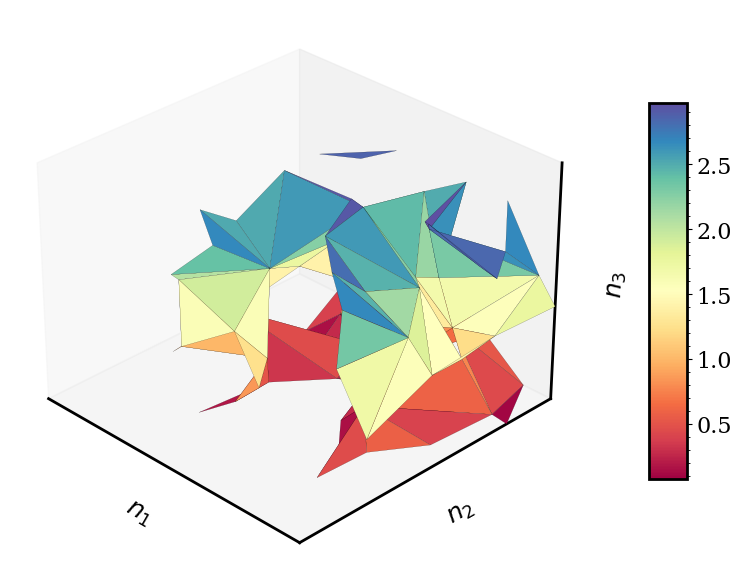

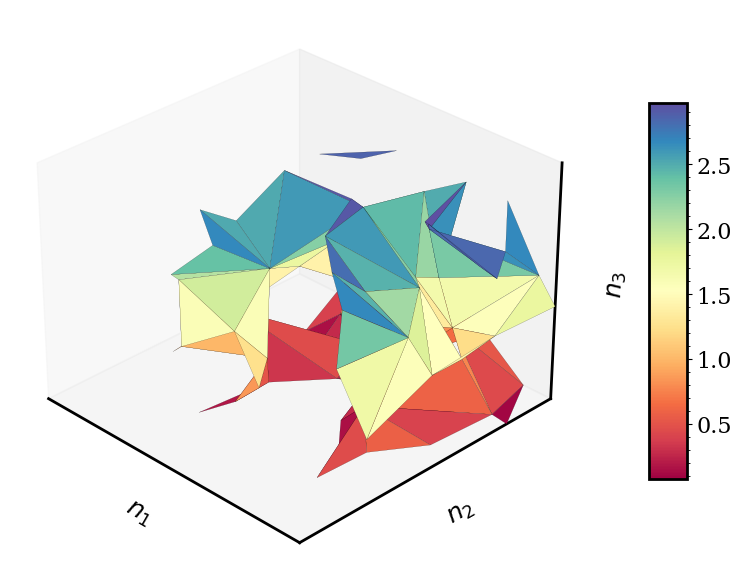

In [75]:
y, ynat = lay.sanity_check()
viz(tf.squeeze(ynat).numpy())
viz(tf.squeeze(y).numpy())

In [74]:
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import cm

# Set rcParams for publication-quality plots
plt.rcParams['figure.figsize'] = (10, 9)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.grid.which'] = 'both'
plt.rcParams['axes.linewidth'] = 2.0  
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['legend.fontsize'] = 16

def viz(volume, level=None, elev=30, azim=135, colormap=cm.Spectral):
    L = volume.shape[1]
    min_val = np.min(volume)
    max_val = np.max(volume)
    if level is None:
        level = (min_val + max_val) * 0.5

    print(f"Volume range: {min_val:.3f} to {max_val:.3f} — using level={level:.3f}")

    # Extract mesh with marching cubes
    verts, faces, _, _ = measure.marching_cubes(volume, level=level)
    face_colors = verts[faces][:, :, 2].mean(axis=1)
    norm = (face_colors - face_colors.min()) / (np.ptp(face_colors) + 1e-8)

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(verts[faces], facecolors=colormap(norm), edgecolor='k', linewidths=0.1, alpha=1.0)
    ax.add_collection3d(mesh)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    ax.set_xlabel('$n_1$')
    ax.set_ylabel('$n_2$')
    ax.set_zlabel('$n_3$')

    ax.view_init(elev=elev, azim=azim)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    plt.tight_layout()

    # Optional: add colorbar
    mappable = cm.ScalarMappable(cmap=colormap)
    mappable.set_array(face_colors)
    plt.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, pad=0.1)
